# Preparation: import libraries and load data

In [1]:
import sys
import numpy as np
import pandas as pd
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from sksurv.util import Surv
import os
import joblib

from sksurv.metrics import concordance_index_censored
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold

import shap

In [2]:
seed = 71

In [3]:
# SELECTION OF NEEDED PARAMETERS
# THE ONLY OTHER BOX TO BE MODIFIED IS THE LIST OF FEATURES TO BE USED IN THE MODEL

# Indicate the outcome of interest ['OS','PSF']
outcome = 'OS'
status = f'STATUS {outcome}'

# Indicate the model to be used ['CPH', 'ST', 'GBS', 'RSF', 'EST', 'SSVM']
file = "RSF_univ.joblib"

# Set this to True if you want to save figures/data, and False otherwise
save_output = True

In [4]:
# Load data
X_train = pd.read_excel("Data/X_train.xlsx").iloc[:, 1:]
X_test  = pd.read_excel("Data/X_test.xlsx").iloc[:, 1:]
y_train_df = pd.read_excel("Data/y_train.xlsx").iloc[:, 1:]
y_test_df  = pd.read_excel("Data/y_test.xlsx").iloc[:, 1:]
y_train_df = y_train_df.rename(columns={status: "event", outcome: "time"})
y_test_df = y_test_df.rename(columns={status: "event", outcome: "time"})
y_tr = Surv.from_dataframe("event", "time", y_train_df)
y_t  = Surv.from_dataframe("event", "time", y_test_df)

In [5]:
def cindex(y_true, y_pred):
    return concordance_index_censored(
        y_true["event"], y_true["time"], y_pred
    )[0]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=31)

def stratify_labels(y):
    return y["event"].astype(int)

class SurvivalUnivariateSelector(BaseEstimator, TransformerMixin):
    def __init__(self, model, threshold=0.55, cv=3):
        self.model = model
        self.threshold = threshold
        self.cv = cv

    def fit(self, X, y):
        Xc = X.copy()
        self.selected_features_ = []

        skf = StratifiedKFold(n_splits=self.cv, shuffle=True, random_state=42)
        strat_labels = stratify_labels(y)

        for col in Xc.columns:
            scores = []

            for train_idx, val_idx in skf.split(Xc, strat_labels):
                X_tr, X_val = Xc.iloc[train_idx][[col]], Xc.iloc[val_idx][[col]]
                y_tr, y_val = y[train_idx], y[val_idx]

                model = clone(self.model)
                model.fit(X_tr, y_tr)
                preds = model.predict(X_val)

                scores.append(cindex(y_val, preds))

            if np.mean(scores) > self.threshold:
                self.selected_features_.append(col)

        if len(self.selected_features_) == 0:
            self.selected_features_ = list(Xc.columns)

        return self

    def transform(self, X):
        Xc = X.copy()
        return Xc[self.selected_features_]

In [6]:
folder = file.replace(".joblib", "")
name, fs = folder.rsplit("_", 1)

# Load pipeline
pipeline = joblib.load(os.path.join("Results", file))

fs_step = pipeline.named_steps.get("fs", None)
m = pipeline.named_steps.get("model", None)

features_model = m.feature_names_in_
if fs=="univ":
    X_tr = X_train[features_model]
    X_t = X_test[features_model]
else:
    X_tr = X_train
    X_t = X_test

In [7]:
# Arrays of risk scores predicted by the model

y_pred_train = m.predict(X_tr)
y_pred_test = m.predict(X_t)

In [8]:
# Expected values of the risk scores (= mean of the predicted values)

exp_value_tr = np.mean(y_pred_train)
print(f"Expected value TRAIN: {exp_value_tr.round(3)}")

exp_value_te = np.mean(y_pred_test)
print(f"Expected value TEST: {exp_value_te.round(3)}")

Expected value TRAIN: 55.302
Expected value TEST: 57.302


# Explainability analysis: building the explainer

In [9]:
# Train the explainer and generate explanations for the TEST set

explainer = shap.Explainer(m.predict, X_tr, seed=seed)
shap_values = explainer(X_t)

ExactExplainer explainer: 115it [19:18, 10.17s/it]                         


Link the SHAP values to the corresponding original data (non-logarithmic and non-normalized), so that Explainability graphs refer to the original data

In [10]:
# Print the list of features selected by the feature selector
print(f'Features for training the model: \n{features_model} \n')

# Array with the original names of the selected features
features_original = np.array([n.removeprefix('log_') for n in features_model])
# Print the list of original selected features
print(f'Original features: \n{features_original}')

Features for training the model: 
['IMDC Score at diagnosis' 'Hb at baseline' 'IMDC Score at baseline IO'
 'KPS' 'Bone metastases' 'PLR at baseline' 'SII at baseline'
 'log_Lymphocytes at baseline' 'log_NLR at baseline'] 

Original features: 
['IMDC Score at diagnosis' 'Hb at baseline' 'IMDC Score at baseline IO'
 'KPS' 'Bone metastases' 'PLR at baseline' 'SII at baseline'
 'Lymphocytes at baseline' 'NLR at baseline']


In [11]:
# Load the corresponding non-logarithmised and non-normalised data
X_test_explainability = pd.read_excel('Data/X_test_expl.xlsx')

# Keep only the original features corresponding to those selected by the feature selector
X_test_explainability = X_test_explainability.loc[:,features_original]
X_test_explainability.columns

Index(['IMDC Score at diagnosis', 'Hb at baseline',
       'IMDC Score at baseline IO', 'KPS', 'Bone metastases',
       'PLR at baseline', 'SII at baseline', 'Lymphocytes at baseline',
       'NLR at baseline'],
      dtype='object')

In [12]:
# Set the feature names in the SHAP values
for i, c in enumerate(features_original):
    shap_values.feature_names[i] = c

# Link the SHAP values to the corresponding original data
shap_values.data = X_test_explainability.values

In [13]:
# Save the explainer and the SHAP values

if save_output:
    with open(f'Explainability/{folder}/explainer.pkl', 'wb') as f:
        pickle.dump(explainer, f)
    with open(f'Explainability/{folder}/shap_values.pkl', 'wb') as f:
        pickle.dump(shap_values, f)

# Explainability plots - test set

## Beeswarm plots

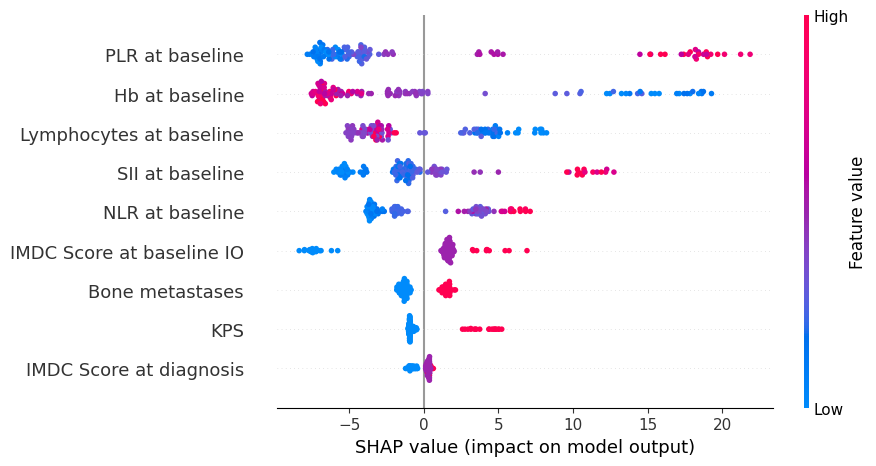

In [41]:
# Plot the SHAP values for all the selected features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=X_tr.shape[1], show=False)
if save_output:
    plt.savefig(f'Explainability/{folder}/Beeswarm_complete.png', format='png', dpi=300, bbox_inches='tight')

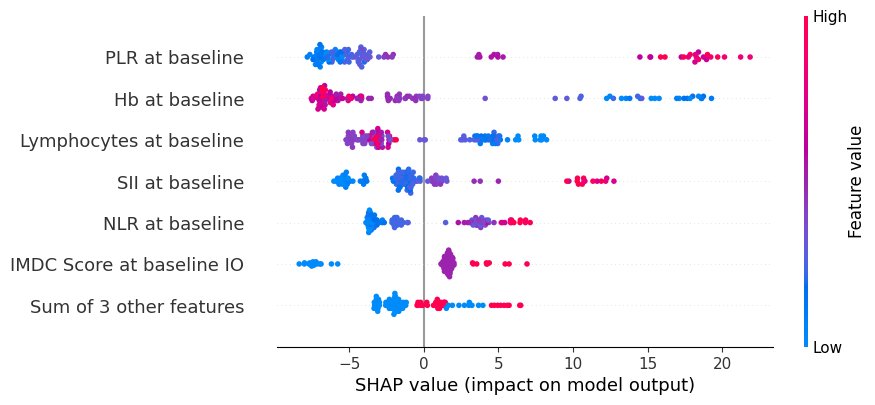

In [42]:
# Plot the SHAP values for the first 6 most important features

plt.figure(figsize=(30, 10))
shap.plots.beeswarm(shap_values, max_display=7, show=False)
if save_output:
    plt.savefig(f'Explainability/{folder}/Beeswarm_reduced.png', format='png', dpi=300, bbox_inches='tight')

## Dependence plots

In [43]:
# Get the 6 most important features
from shap.plots._utils import convert_ordering

order = shap_values.abs.mean(0)
values = np.copy(shap_values.values)
order = convert_ordering(order, values)

most_imp_feats = features_original[order[:6]]
print(most_imp_feats)

['PLR at baseline' 'Hb at baseline' 'Lymphocytes at baseline'
 'SII at baseline' 'NLR at baseline' 'IMDC Score at baseline IO']


C:\Users\sferr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\shap\plots\_scatter.py:221: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = pl.figure(figsize=figsize)


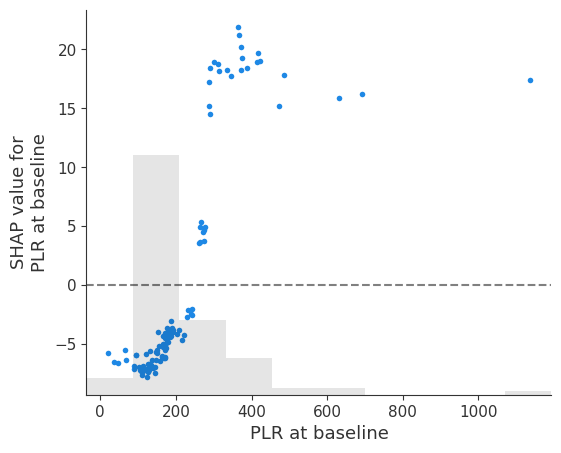

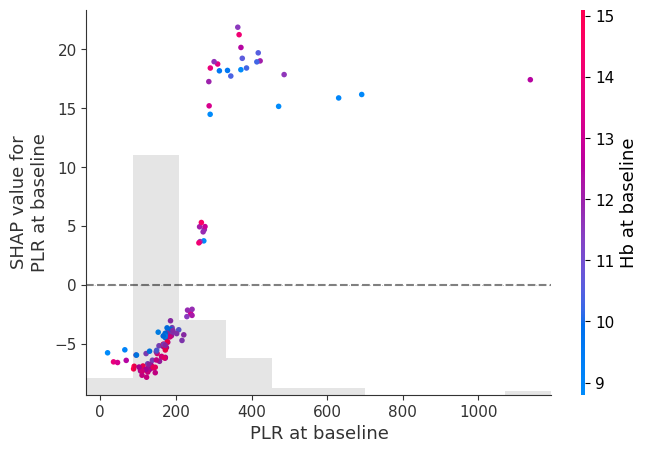

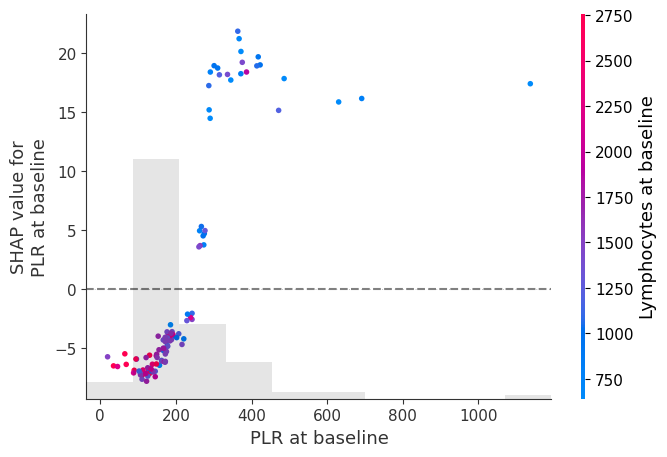

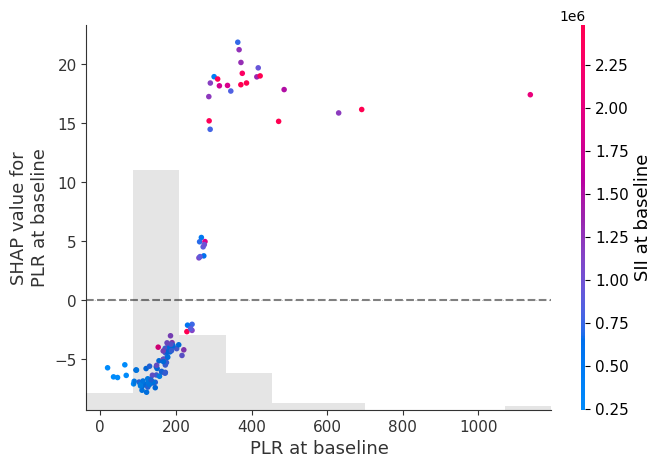

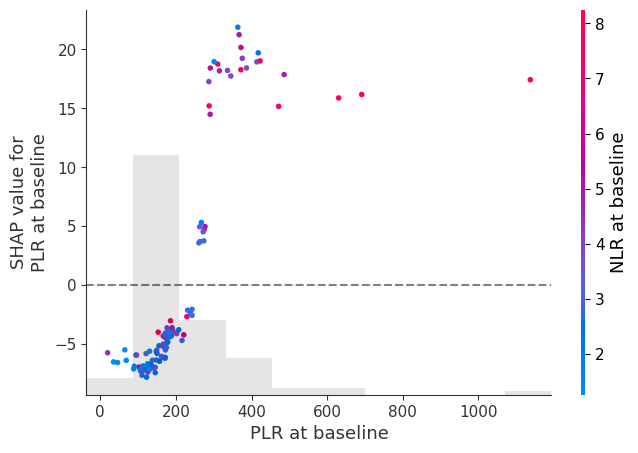

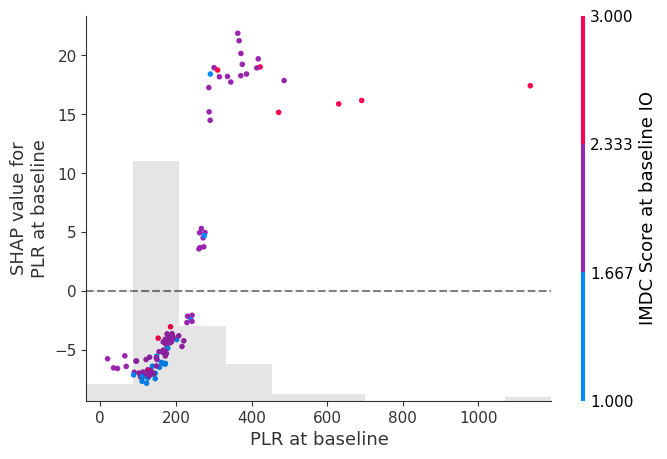

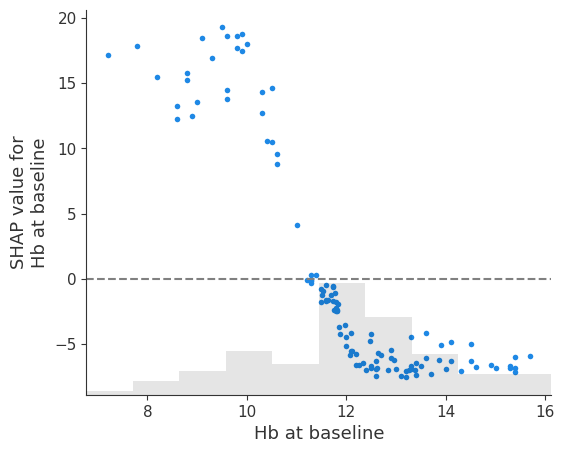

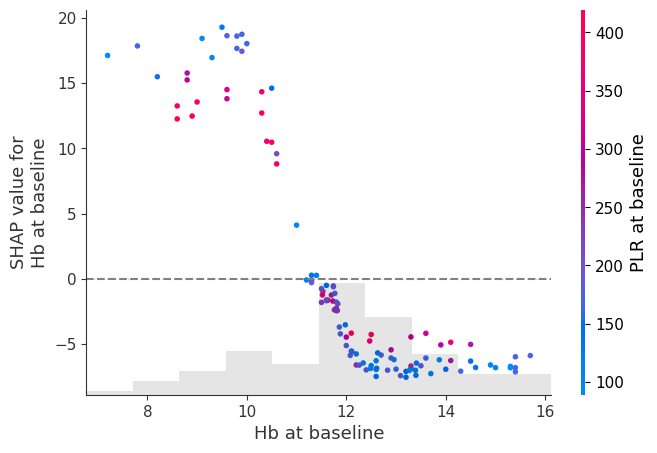

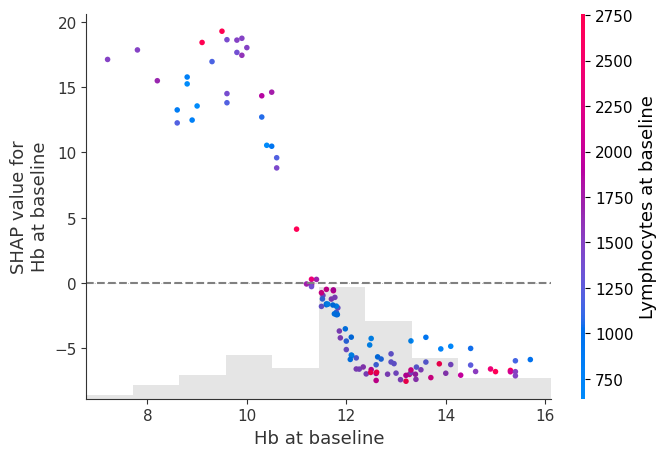

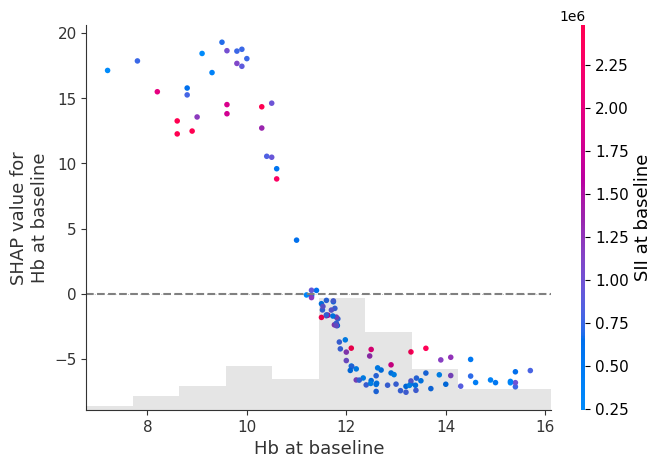

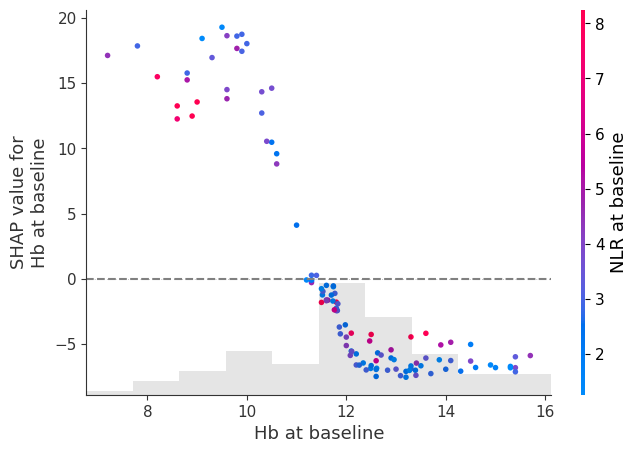

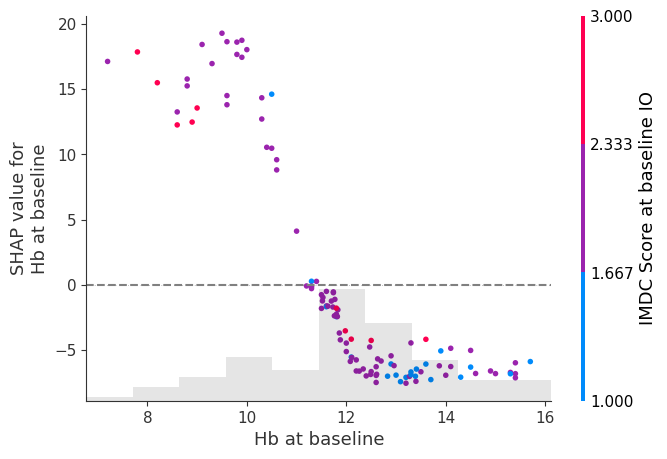

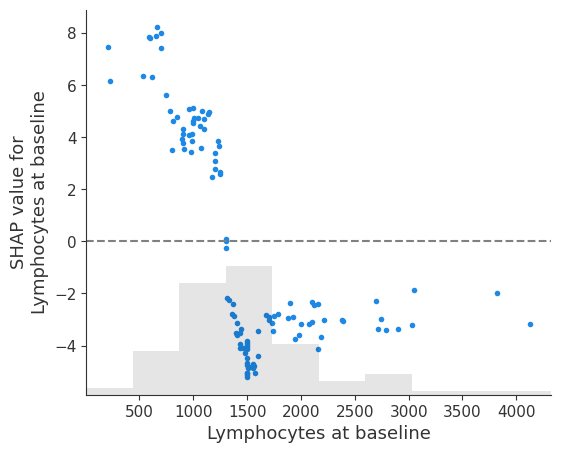

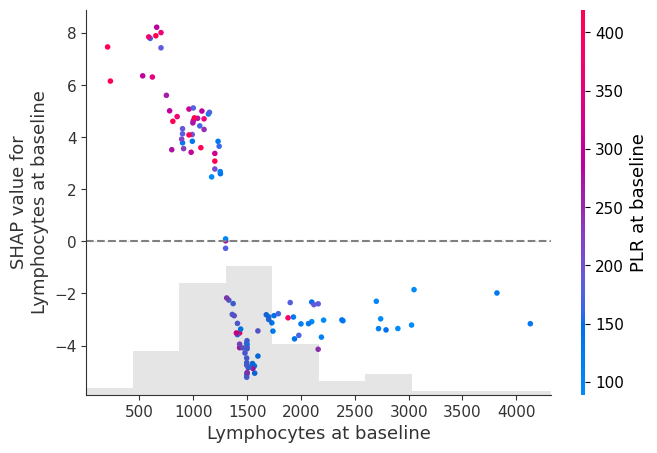

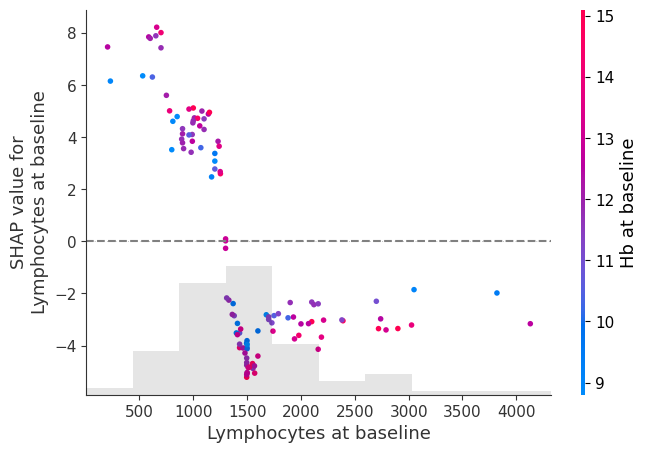

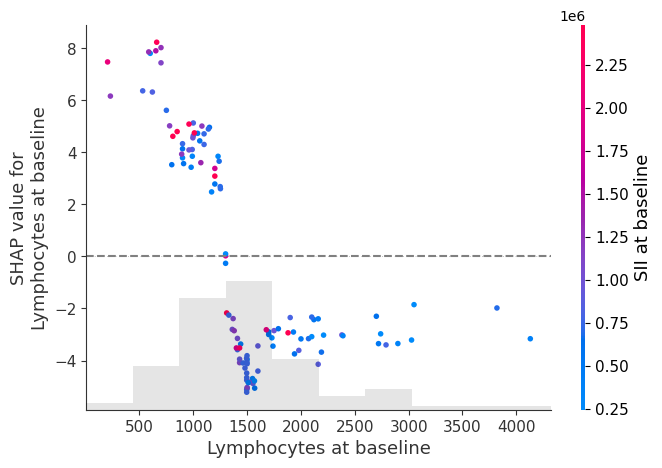

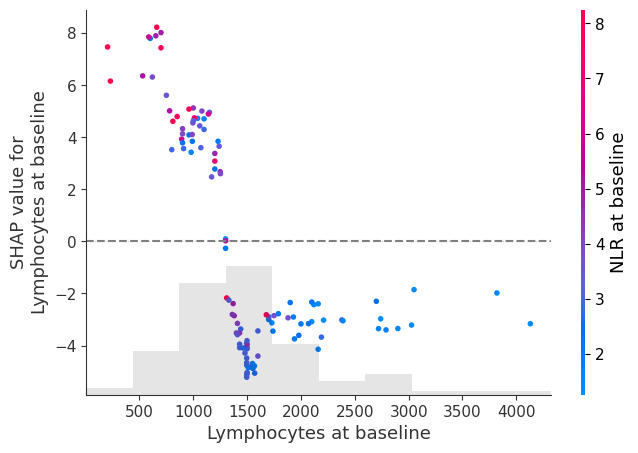

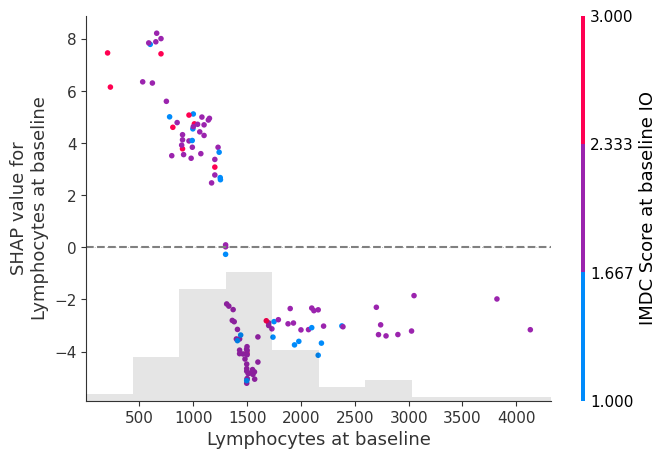

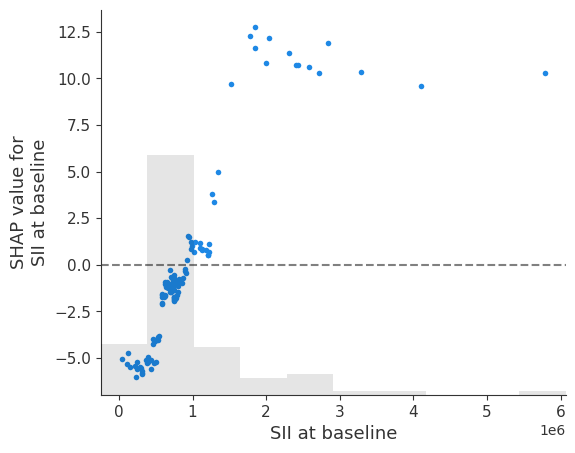

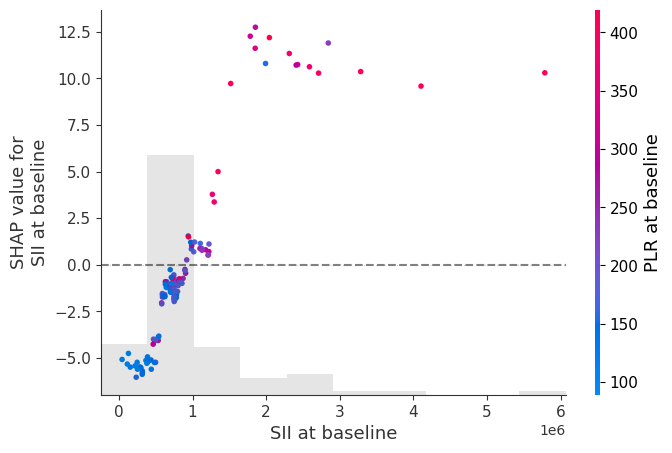

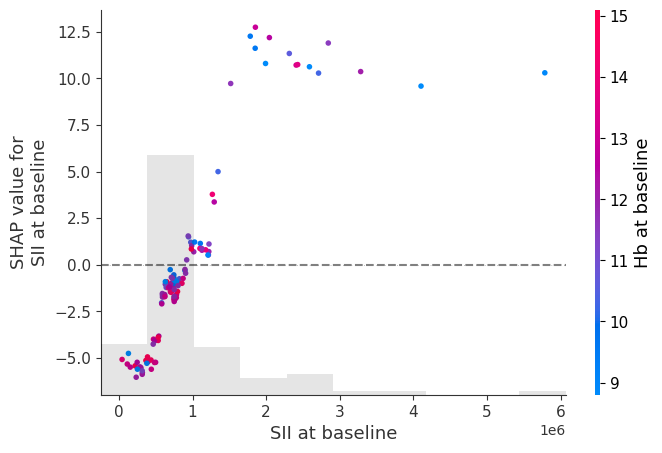

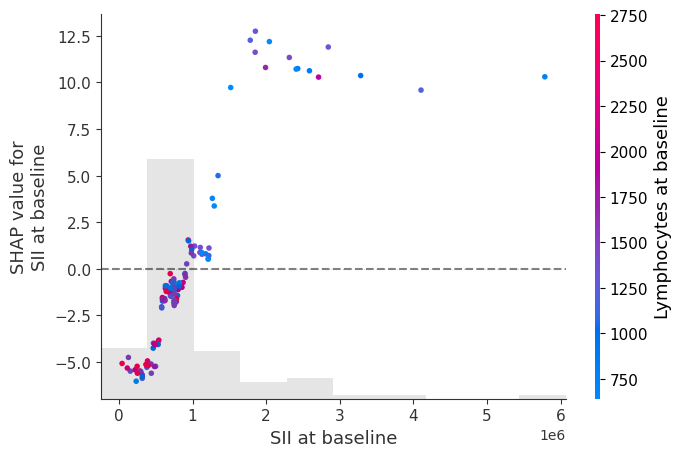

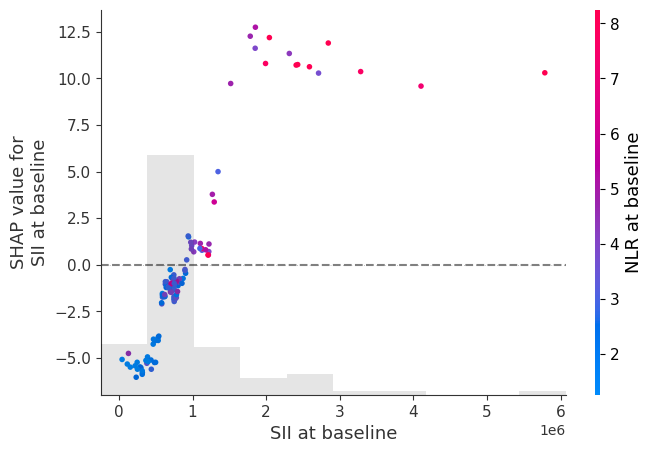

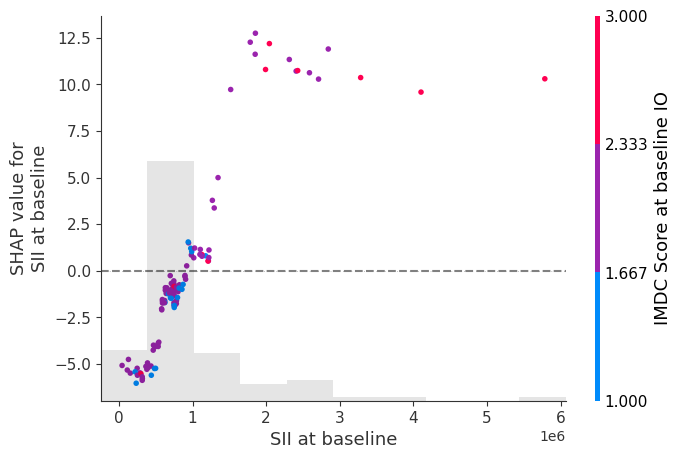

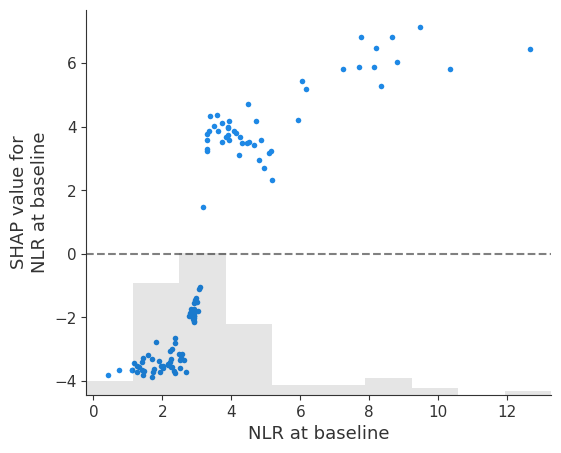

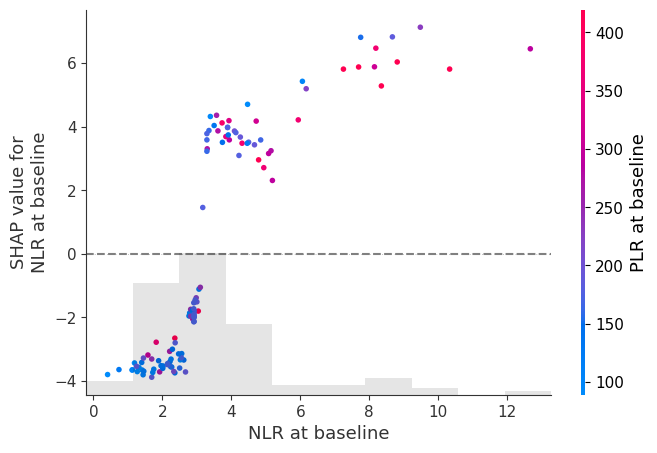

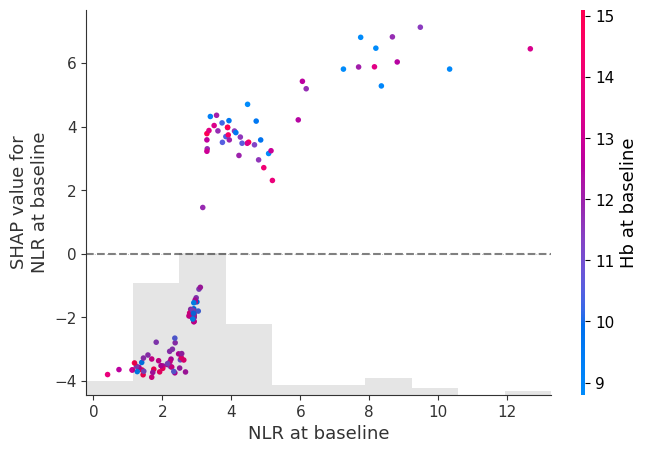

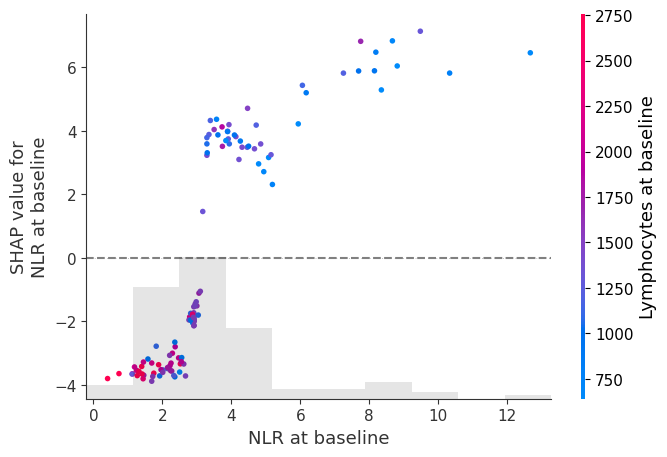

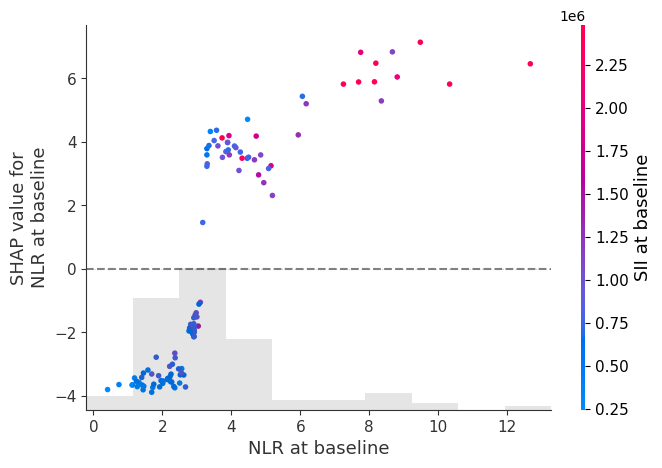

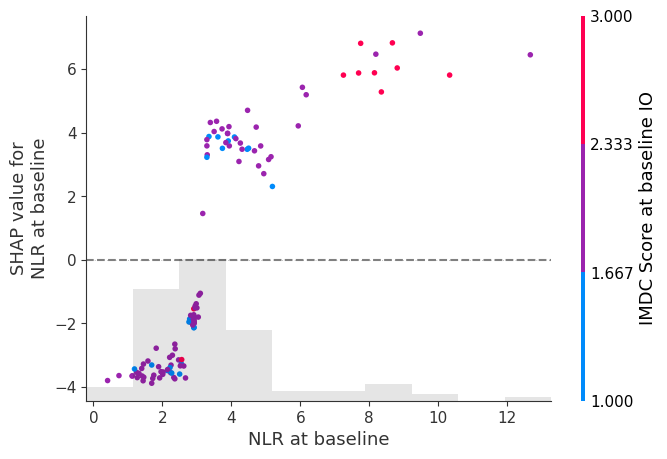

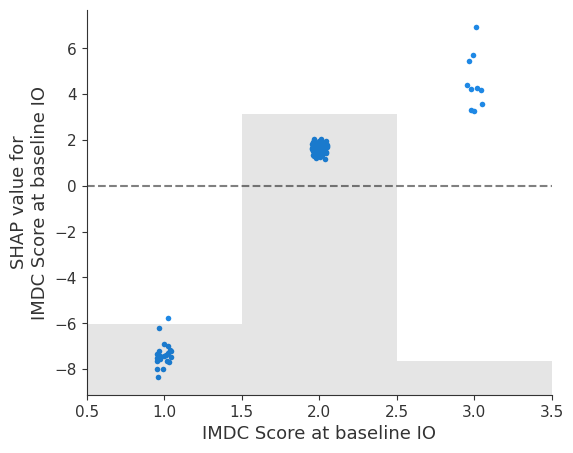

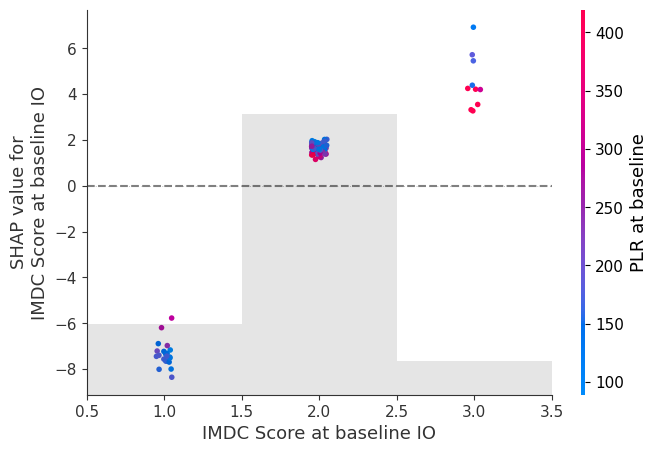

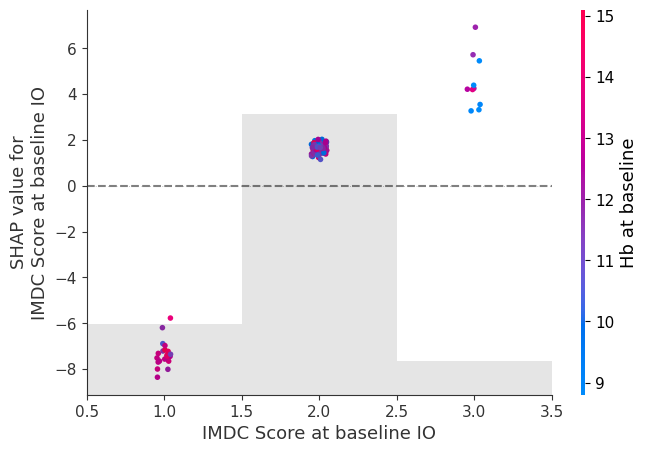

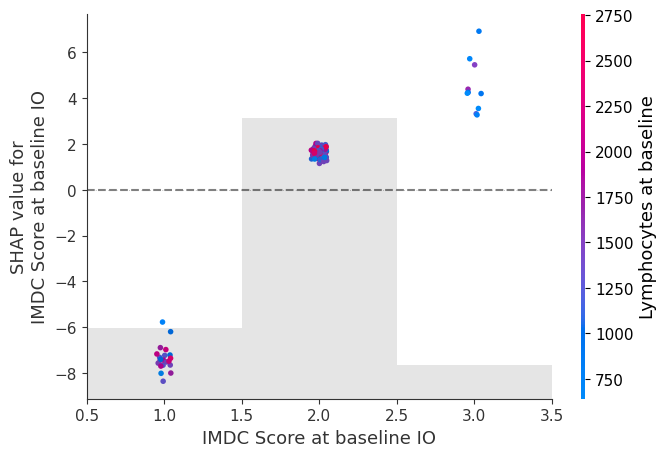

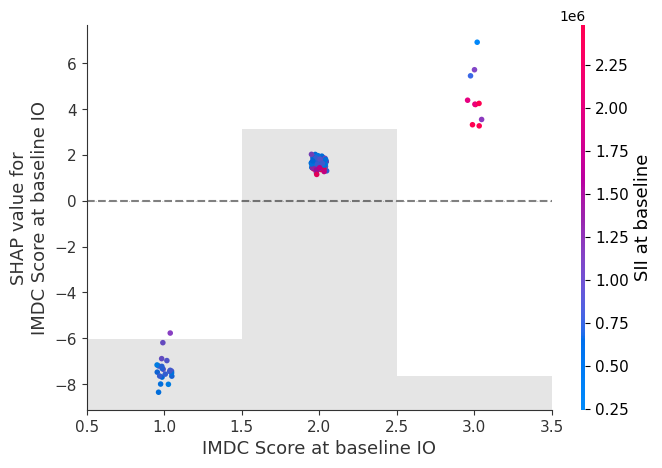

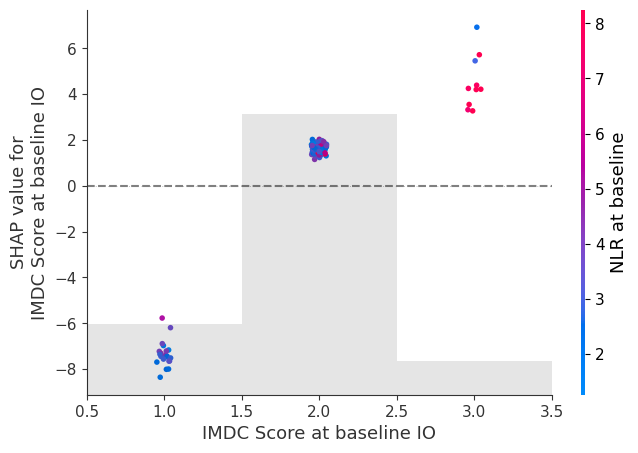

In [44]:
for i in range(6):

    # Plot SHAP scatter plot
    shap.plots.scatter(shap_values[:, most_imp_feats[i]], show=False)
    # Draw the horizontal line corresponding to SHAP values equal to zero
    plt.axhline(0, linestyle="--", color='grey')

    if save_output:
        plt.savefig('Explainability/{fld}/Scatter_{f1}.png'.format(fld=folder, f1=most_imp_feats[i]), format='png', dpi=300, bbox_inches='tight')
    
    for j in range(6):
        if j != i:

            # Plot SHAP scatter plot
            shap.plots.scatter(shap_values[:, most_imp_feats[i]], color=shap_values[:, most_imp_feats[j]], show=False)
            # Draw the horizontal line corresponding to SHAP values equal to zero
            plt.axhline(0, linestyle="--", color='grey')

            if save_output:
                plt.savefig('Explainability/{fld}/Dependence_{f1}_{f2}.png'.format(fld=folder, f1=most_imp_feats[i], f2=most_imp_feats[j]), format='png', dpi=300, bbox_inches='tight')

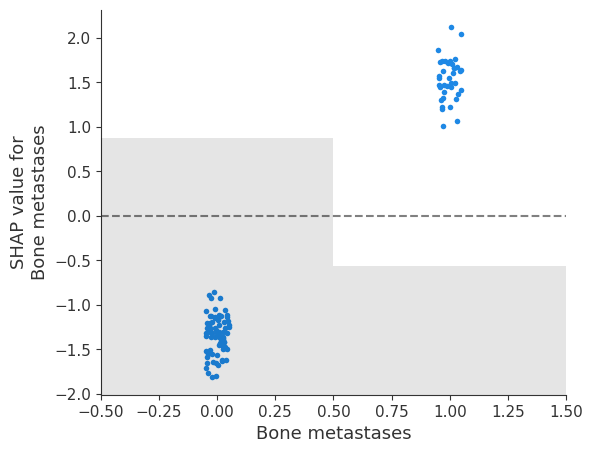

In [45]:
# Plot SHAP scatter plot
shap.plots.scatter(shap_values[:, 'Bone metastases'], show=False)
# Draw the horizontal line corresponding to SHAP values equal to zero
plt.axhline(0, linestyle="--", color='grey')

if save_output:
    plt.savefig('Explainability/{fld}/Scatter_{f1}.png'.format(fld=folder, f1='Bone metastases'), format='png', dpi=300, bbox_inches='tight')

## Waterfall plots

In [18]:
# Look at the array y_test and select the indexes of the column 'index'
# corresponding to the patients dead/progressed in short time, in long time,
# and censored patients

## Decision plots

In [19]:
# Preparation
import my_decision_plot

# Array of SHAP values for the test set
shap_vs = shap_values.values

In [46]:
# Index of the patient with the lowest predicted risk score
pt = y_pred_test.argmin() 

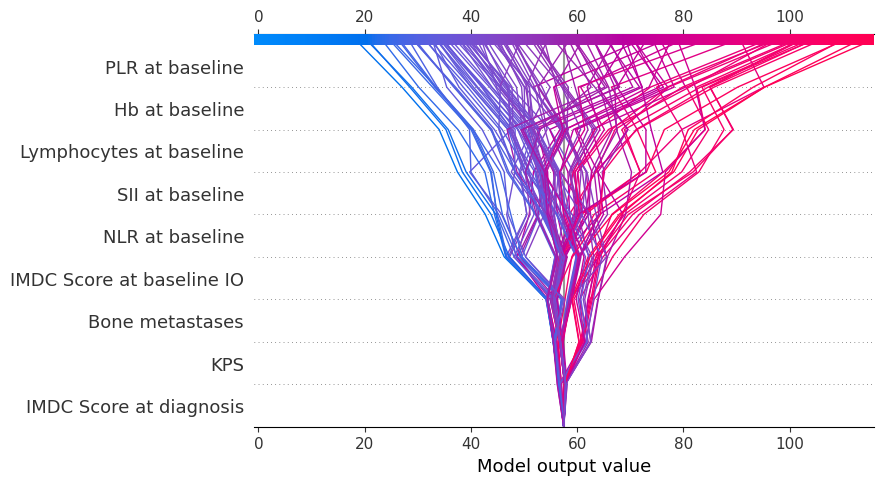

In [47]:
# Default: display all features in reverse order

r = shap.plots.decision(
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    color_bar = True,
    show=False,
    return_objects=True
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_default.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

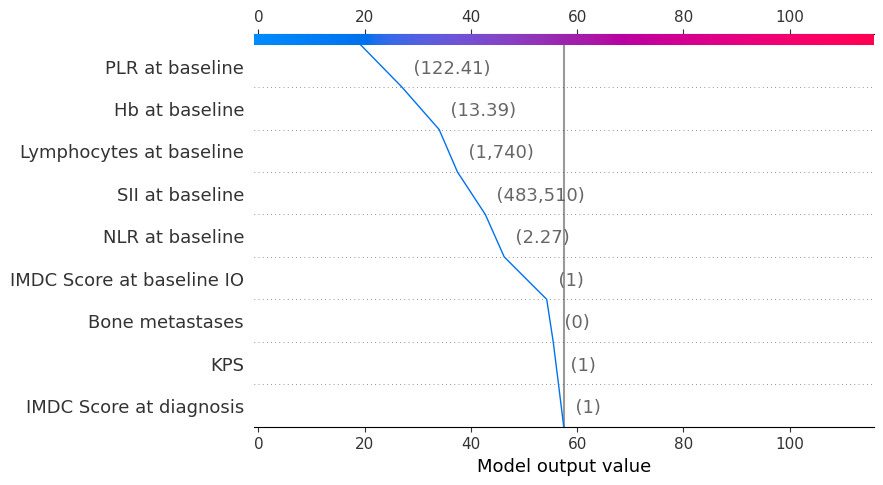

In [48]:
# ONLY ONE PATIENT

shap.plots.decision(
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values[pt], # SHAP values
    features = shap_values.data[pt], # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_order = r.feature_idx, # hierarchical clustering
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    show=False,
    xlim = r.xlim
)

if save_output:
    plt.savefig(f'Explainability/{folder}/pt{pt}_Decision_default.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Colors based on features values for each segment of the lines

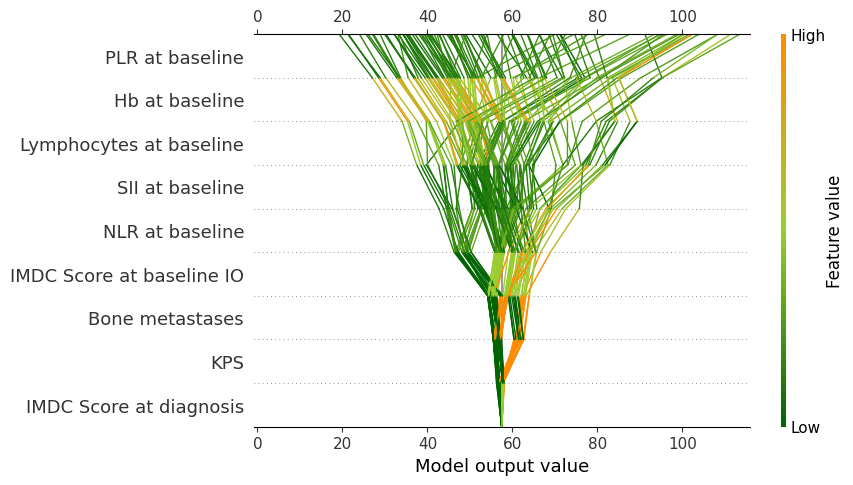

In [49]:
# Modified decision plot with all the features in reverse order

my_decision_plot.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    show=False
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_mod_imp_compl.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

### Aggregated features in the middle of the graph

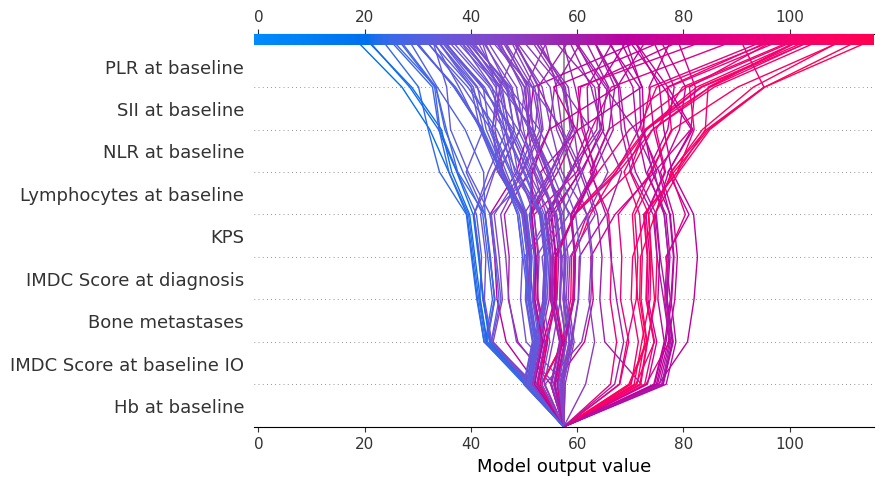

In [50]:
# Default decision plot with all the features with hierarchical clustering

r = shap.plots.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_order='hclust', # hierarchical clustering
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    show=False,
    return_objects=True
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_def_hier_complete.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

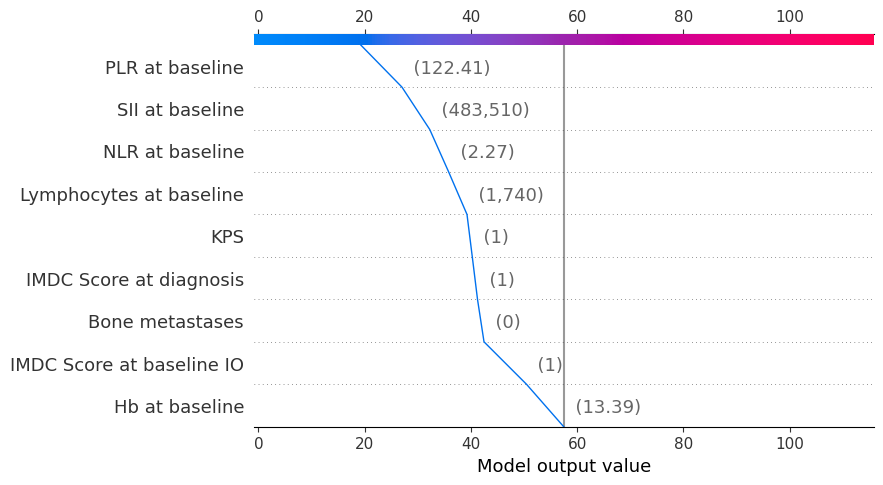

In [51]:
# ONLY ONE PATIENT

shap.plots.decision(
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values[pt], # SHAP values
    features = shap_values.data[pt], # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_order = r.feature_idx, # hierarchical clustering
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    show=False,
    xlim = r.xlim
)

if save_output:
    plt.savefig(f'Explainability/{folder}/pt{pt}_Decision_hier.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

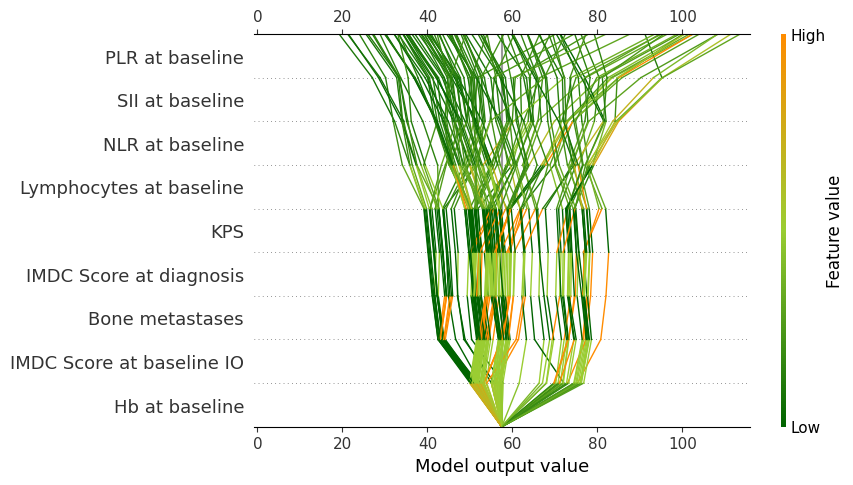

In [52]:
# Modified decision plot with all the features with hierarchical clustering

my_decision_plot.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_order='hclust', # hierarchical clustering
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    show=False
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_mod_hier_complete.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

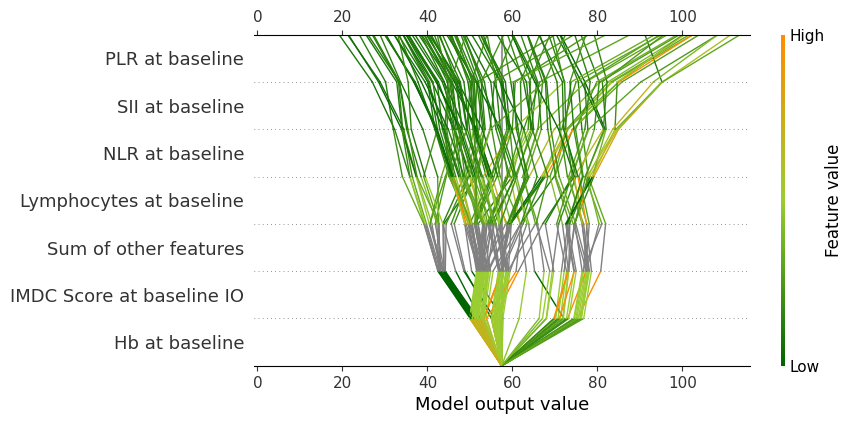

In [53]:
# Modified decision plot with hierarchical clustering with n_top features at the top,
# n_bottom features at the bottom and the rest aggregated in the middle

my_decision_plot.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_order ='hclust', # hierarchical clustering
    n_top = 4, # display n_top features at the top
    n_bottom = 2, # display n_bottom features at the bottom
    show=False
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_mod_hier_top-bot.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

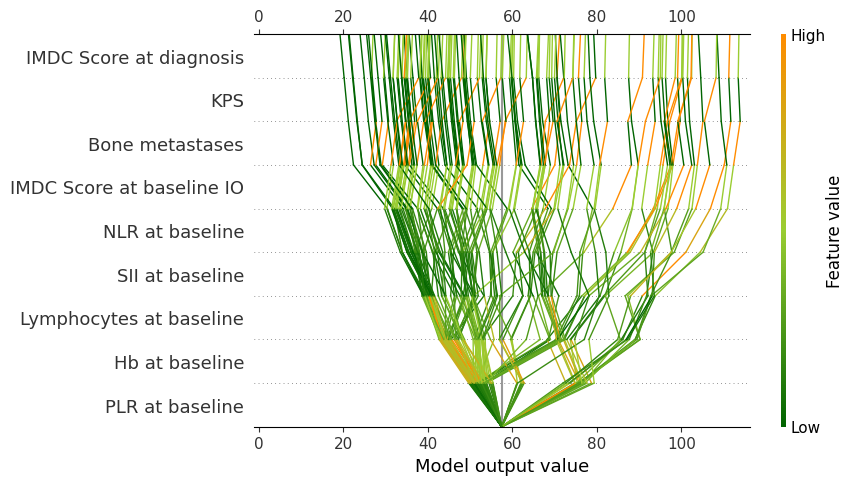

In [54]:
# Modified decision plot with all the features in actual order of importance

my_decision_plot.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    feature_display_range = slice(None, None, -1), # display all features in reverse order
    reverse=True, # reverse the order of the features
    show=False
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_mod_imp-down_compl.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

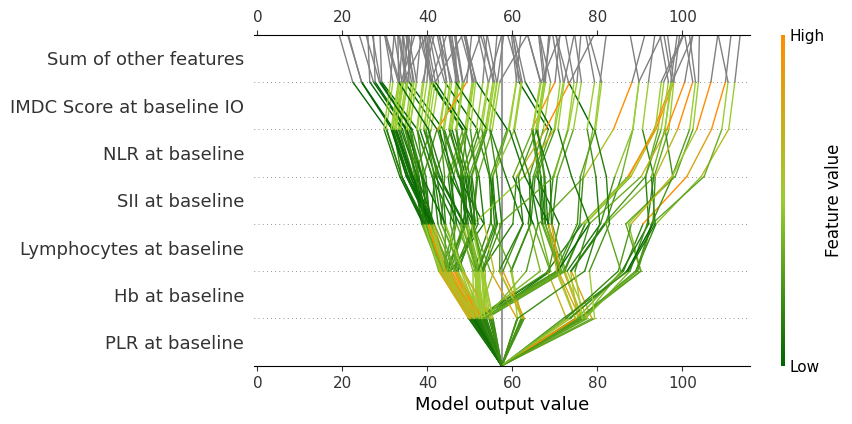

In [55]:
# Modified decision plot with the n_bottom most important features at the bottom

my_decision_plot.decision(
    #base_value = exp_value_te, # reference value that the feature contributions start from
    #shap_values = shap_vs, # SHAP values
    #features = X_test_explainability, # matrix of feature values (non-normalized and non-log-transformed)
    base_value = shap_values.base_values[0], # reference value that the feature contributions start from
    shap_values = shap_values.values, # SHAP values
    features = shap_values.data, # matrix of feature values (non-normalized and non-log-transformed)
    feature_names = shap_values.feature_names,
    n_bottom = 6, # display the n_bottom most important features at the bottom
    n_top = 0,
    reverse = True, # reverse the order of the features
    show=False
)

if save_output:
    plt.savefig(f'Explainability/{folder}/Decision_mod_imp-down_bot.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

## Heatmap plots

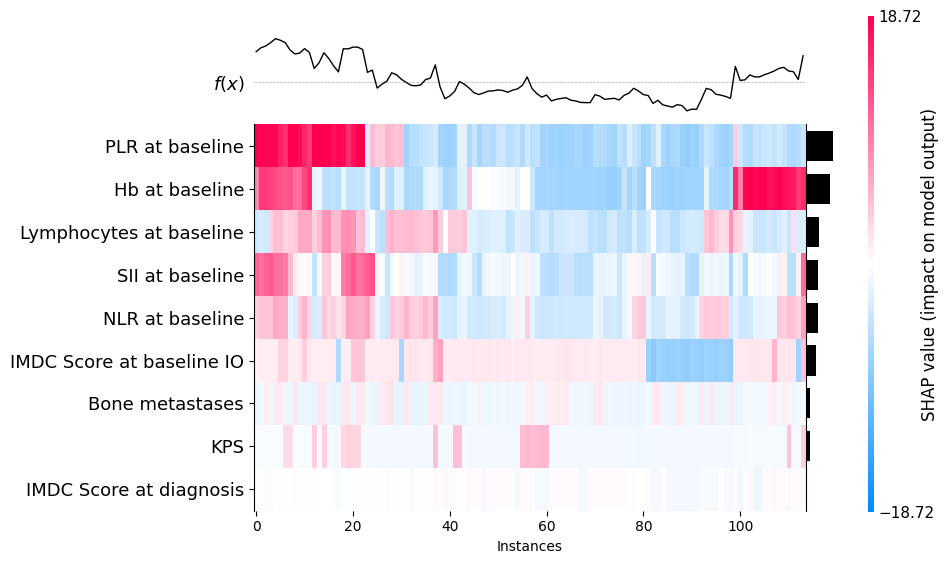

In [27]:
# Default

shap.plots.heatmap(shap_values, show=False)

if save_output:
    plt.savefig(f'Explainability/{folder}/Heatmap_default.png', format='png', bbox_inches='tight')
plt.show()

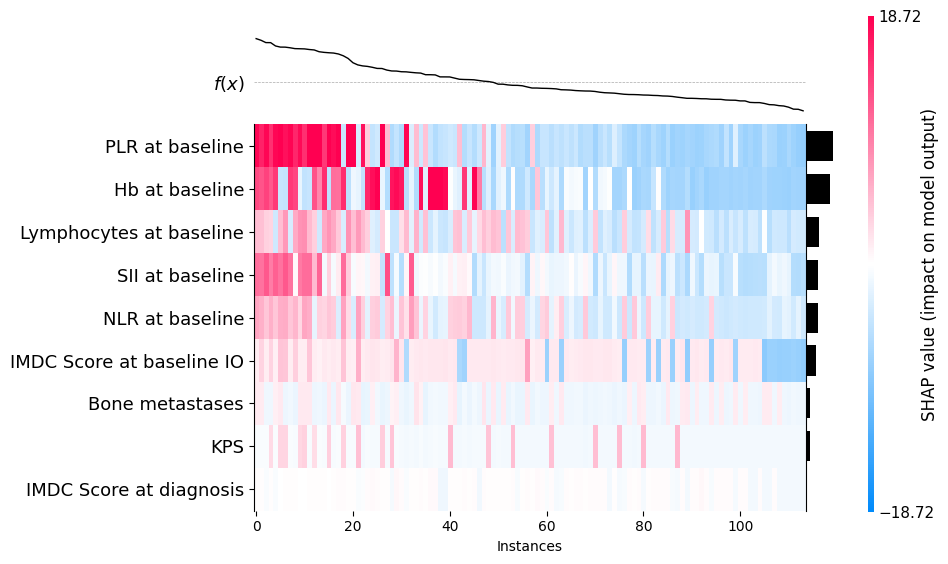

In [28]:
# The ordering of the inmstances along the x axis can be controlled with the parameter instance_order:
# by default, that parameter is set to shap.Explanation.hclust(0) to group samples with similar explantions together;
# you can set it to shap_values.sum[1] to sort by the sum of the SHAP values over all features.

shap.plots.heatmap(shap_values, instance_order=shap_values.sum(1), show=False)

if save_output:
    plt.savefig(f'Explainability/{folder}/Heatmap_inst_order.png', format='png', bbox_inches='tight')
plt.show()

# (The instance on the left has the maximum sum of SHAP values over all features: if you sum the 
# shap values of each feature associated to that instance, you obtain the maximum value;
# while the instance on the right has the minimum sum of SHAP values over all features: if you sum
# the shap values of each feature associated to that instance, you obtain the minimum value.)